# Tutorial COZIpy

In this short turorial, we showcase the usage of COZIpy on a smiulated test dataset.

In [ ]:
import numpy as np
from cozipy.neighbors import knn_graph, radius_graph, delaunay_graph
from cozipy.nep_cozi import run_cozi
import os
import pandas as pd
import matplotlib.pyplot as plt

## Running COZIpy Analysis

COZIpy analyzes the spatial organization of cell types by computing binary neighbor preferences (NEP). The analysis requires:

- **Coordinates**: x and y spatial coordinates for each cell
- **Labels**: Cell type annotation for each cell

### Neighborhood Definition

COZIpy supports three methods to define cell neighborhoods:

| Method | `nbh_def` Parameter | Config Parameter | Description |
|--------|-------------------|------------------|-------------|
| **KNN** | `"knn"` | `n_neighbors` | k-nearest neighbors approach |
| **Radius** | `"radius"` | `radius` | Fixed radius around each cell |
| **Delaunay** | `"delaunay"` | - | Delaunay triangulation-based neighbors |

### Analysis Parameters

Key parameters to configure:

- `n_permutations`: Number of random permutations for significance testing (default: 100)
- `random_state`: Seed for reproducibility
- `min_cell_count`: Filter out cell types with fewer cells (default: 0, no filtering)
- `normalize_zscore`: Normalize z-scores by √(total cell count) for cross-sample comparison (default: False)
- `fixed_type`: Keep a specific cell type fixed during permutations (optional)

### Note

Analysis runs per sample. If working with multiple images, loop through each image individually. In this tutorial, we demonstrate with a single image.

In [3]:
# read csv file
df = pd.read_csv("./test_data/test_sim_data.csv")

coords = df[["x", "y"]].values
labels = df["ct"].values.astype(int)

# run cozi with either delaunay, radius, or knn neighborhood definitions
res = run_cozi(coords,
               labels,
               nbh_def="knn",
               n_neighbors=10,
               n_permutations=300,
               random_state=0,
               min_cell_count=20,
               return_df=True,
               normalize_zscore=False)

The result is a data frame with on line per interaction. Per interaction, the number of index cells, the number of neighbor cells, the calculated z-score and conditional cell ratio are listed.

In [4]:
res

,index_ct,neighbor_ct,index_ct_counts,neighbor_ct_counts,zscore,cond_ratio
0,0,0,448,1211,-0.589305,0.957265
1,0,1,461,1489,0.803728,0.985043
2,0,2,429,1014,-0.608913,0.916667
3,0,3,415,966,0.396652,0.886752
4,1,0,537,1509,1.012490,0.969314
5,1,1,539,1766,1.190332,0.972924
6,1,2,498,1152,-1.521137,0.898917
7,1,3,498,1113,-1.448637,0.898917
8,2,0,372,1034,0.382892,0.948980
9,2,1,380,1167,-1.600014,0.969388


We can visualize the data by plotting a dotplot to illusrate the neighbor preferences.

In [12]:
def cozi_dotplot(res):
    """Visualize NEP results as a dot plot.
    
    Parameters
    ----------
    res : DataFrame
        Output from run_cozi with columns: index_ct, neighbor_ct, zscore, cond_ratio.
    """
    types = sorted(res["index_ct"].unique())
    n = len(types)
    
    z_matrix = res.pivot(index="index_ct", columns="neighbor_ct", values="zscore").loc[types, types].values
    c_matrix = res.pivot(index="index_ct", columns="neighbor_ct", values="cond_ratio").loc[types, types].values
    
    xs, ys = np.meshgrid(range(n), range(n))

    fig, ax = plt.subplots(figsize=(5.5, 6))

    sc = ax.scatter(xs, ys,
                    c=z_matrix.flatten(),
                    s=(c_matrix.flatten() * 600),
                    cmap="coolwarm")

    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(types, rotation=90)
    ax.set_yticklabels(types)
    ax.set_xlabel("Neighbor cell type", fontsize=12)
    ax.set_ylabel("Index cell type", fontsize=12)
    ax.invert_yaxis()

    ax.set_xlim(-0.5, n - 0.5)
    ax.set_ylim(n - 0.5, -0.5)

    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label("z-score")

    for val in [0.25, 0.5, 0.75, 1.0]:
        ax.scatter([], [], s=val * 600, color="gray", label=f"{val:.2f}")

    ax.legend(title="cond_ratio",
              frameon=False,
              loc="upper center",
              bbox_to_anchor=(0.5, -0.25),
              ncol=4)

    plt.tight_layout()
    plt.show()


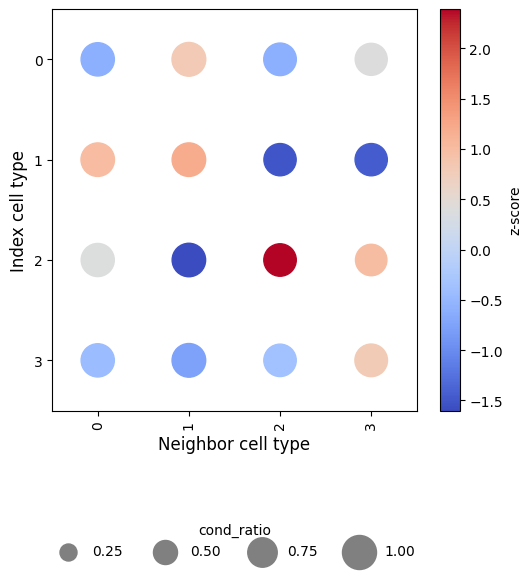

In [13]:
cozi_dotplot(res)

### Citation
Please cite 
>Schiller, C. et al. Comparison and optimization of cellular neighbor preference methods for quantitative tissue analysis. Nat Commun 17, 3514 (2026). https://doi.org/10.1038/s41467-026-71699-z